In [1]:
from utils import load_nested_results
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

results = load_nested_results("results")

In [2]:
map_names = {
    "2_annthyroid": "01",
    "4_breastw": "02",
    "14_glass": "03",
    "15_Hepatitis": "04",
    "21_Lymphography": "05",
    "23_mammography": "06",
    "27_PageBlocks": "07",
    "29_Pima": "08",
    "37_Stamps": "09",
    "38_thyroid": "10",
    "39_vertebral": "11",
    "40_vowels": "12",
    "42_WBC": "13",
    "44_Wilt": "14",
    "45_wine": "15",
    "47_yeast": "16",
}

datasets_names = sorted(list(results.keys()))
model_names = sorted(results[datasets_names[0]].keys() - {"ground_truth"})
n_models = len(model_names)
n_fold = len(results[datasets_names[0]][model_names[0]])

rows = []
for ds_name in list(datasets_names):
    for mod_name in model_names:
        for fold in range(5):
            time_data = results[ds_name][mod_name][fold]["times"]
            for method, time_val in time_data.items():
                rows.append(
                    {
                        "dataset": ds_name,
                        "modele": mod_name,
                        "fold": fold,
                        "methode": method,
                        "temps": time_val,
                    }
                )

df = pd.DataFrame(rows)

df = df.sort_values(by="dataset", key=lambda col: col.str.split("_").str[0].astype(int))
df = df.sort_index(axis=0)

df["dataset"] = df["dataset"].map(map_names)

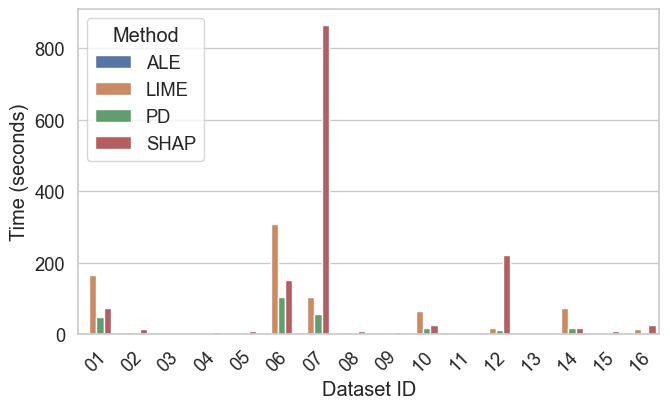

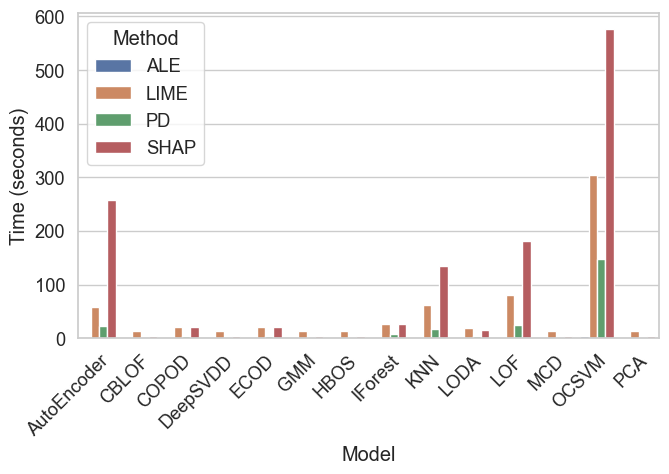

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = df.reset_index(drop=True)

dataset_order = sorted(map_names.values())
df["dataset"] = pd.Categorical(df["dataset"], categories=dataset_order, ordered=True)

model_order = sorted(df["modele"].unique())
df["modele"] = pd.Categorical(df["modele"], categories=model_order, ordered=True)

sns.set_theme(style="whitegrid", font_scale=1.2)

fixed_margins = {"bottom": 0.25, "left": 0.12, "right": 0.95, "top": 0.90}


fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x="dataset", y="temps", hue="methode", errorbar=None, ax=ax1)

ax1.set_ylabel("Time (seconds)")
ax1.set_xlabel("Dataset ID")
ax1.legend(title="Method", loc="upper left")
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

fig1.subplots_adjust(**fixed_margins)

# fig1.savefig("img/time_per_dataset.eps", format="eps")
plt.show()
plt.close(fig1)


fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x="modele", y="temps", hue="methode", errorbar=None, ax=ax2)

ax2.set_ylabel("Time (seconds)")
ax2.set_xlabel("Model")
ax2.legend(title="Method", loc="upper left")
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

fig2.subplots_adjust(**fixed_margins)

# fig2.savefig("img/time_per_model.eps", format="eps")
plt.show()
plt.close(fig2)